In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import re
from PIL import Image
from collections import defaultdict
import math

In [2]:
LABEL_MAP = {
    1: "Starfish", 2: "Crab", 3: "Black goby", 4: "Wrasse", 
    5: "Two-spotted goby", 6: "Cod", 7: "Painted goby", 8: "Sand eel", 
    9: "Whiting"
}

BRIGHT_COLORS = [
    '#FF6600',  # Orange (KEPT)
    '#3366FF',  # Bright Blue (DELETED)
]

In [3]:


def generate_dynamic_ratio_ticks(all_data, N_BINS, plot_min, plot_max):
    """
    Generates a limited, non-overlapping set of numerical ticks (rounded ratio values)
    based on the data spread.
    """
    # Rounding is critical to group ratios like 1.777 and 1.778 together
    unique_ratios = sorted(list(set(np.round(all_data, 3).tolist()))) 
    
    data_range = plot_max - plot_min
    # Set a distance threshold (e.g., 2 times the bin width) to prevent label clutter
    min_distance = data_range / N_BINS * 2.0 

    dynamic_ticks = []
    dynamic_labels = []
    
    if not unique_ratios:
        return dynamic_ticks, dynamic_labels
        
    # Start with the first ratio
    # Ensure the tick is within the plotted range
    if unique_ratios[0] >= plot_min:
        dynamic_ticks.append(unique_ratios[0])
        dynamic_labels.append(f"{unique_ratios[0]:.2f}")

    for i in range(1, len(unique_ratios)):
        # Only add a tick if it is sufficiently far from the previous one AND within the plot range
        if unique_ratios[i] - dynamic_ticks[-1] > min_distance and unique_ratios[i] <= plot_max:
            dynamic_ticks.append(unique_ratios[i])
            dynamic_labels.append(f"{unique_ratios[i]:.2f}")
            
    return dynamic_ticks, dynamic_labels




In [4]:
# --- HELPER: Class Extraction ---
def extract_class_from_path(path):
    """
    Extract the single digit class ID (1-9) immediately preceded by an underscore 
    and followed by the file extension.
    """
    filename = os.path.basename(path)
    match = re.search(r"\_(\d)(?=\.[^\.]*$)", filename, flags=re.IGNORECASE)
    if not match: return -1 
    return int(match.group(1))


In [4]:


# --- EXTRACTION FUNCTION 1: Overall Dataset (Goal 2) ---

def extract_overall_ratios(directory_path):
    """
    Iterates through images in a directory, calculates the aspect ratio, and groups 
    the ratios by the class ID extracted from the filename.
    
    Returns:
        dict: {class_id (int): [list_of_ratios (float)]}
    """
    print(f"1. Extracting overall ratio data from files in: {directory_path}")
    ratio_by_class = defaultdict(list)
    
    for filename in os.listdir(directory_path):
        if filename.startswith('.'): continue

        full_path = os.path.join(directory_path, filename)
        if not os.path.isfile(full_path): continue
            
        class_id = extract_class_from_path(full_path)
        if class_id not in LABEL_MAP: continue
            
        try:
            img = Image.open(full_path)
            width, height = img.size
            if height != 0:
                aspect_ratio = width / height
                ratio_by_class[class_id].append(aspect_ratio)
            
        except Exception:
            pass

    print(f"   ✅ Data extracted for {len(ratio_by_class)} classes.")
    return ratio_by_class


In [11]:
def plot_overall_ratio_histograms_3x3(ratio_by_class_dict, N_BINS=50):
    """
    Plots a histogram of aspect ratio for each class in a 3x3 multi-subplot layout, 
    sharing X and Y axes, with dynamic numerical ticks visible on ALL plots.
    """
    unique_classes = sorted(ratio_by_class_dict.keys())
    
    all_ratios = np.concatenate([ratios for ratios in ratio_by_class_dict.values()])
    
    if all_ratios.size == 0:
         print("Error: Combined ratio data is empty. Cannot plot.")
         return

    min_ratio = np.min(all_ratios)
    max_ratio = np.max(all_ratios)
    
    plot_min = max(0.1, min_ratio - 0.1)
    plot_max = min(5.0, max_ratio + 0.1)
    
    bin_edges = np.linspace(plot_min, plot_max, N_BINS + 1)
    
    dynamic_ticks, dynamic_labels = generate_dynamic_ratio_ticks(all_ratios, N_BINS, plot_min, plot_max)
    
    n_rows = 3
    n_cols = 3
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 15), sharex=True, sharey=True)
    fig.suptitle("Overall Aspect Ratio Distribution per Class (Shared Scales)", fontsize=16, y=1.02)
    
    axes_flat = axes.flatten()
    x_label = "Aspect Ratio (Width / Height)"
    
    for i, cls in enumerate(range(1, 10)):
        ax = axes_flat[i]
        ratios = ratio_by_class_dict.get(cls, [])
        plot_color = '#1f77b4'
        
        if not ratios:
            ax.set_title(f"Class {cls}: {LABEL_MAP.get(cls, 'Unknown')} (N=0)", fontsize=10)
            ax.axis('off')
            continue
            
        ax.hist(ratios, bins=bin_edges, edgecolor='black', alpha=0.8, color=plot_color)
        
        # *** KEY CHANGE: Force tick labels visible on all plots ***
        ax.set_xticks(dynamic_ticks)
        ax.set_xticklabels(dynamic_labels, rotation=30, ha='right', fontsize=8)
        ax.tick_params(axis='x', which='both', bottom=True, labelbottom=True)
        
        # X-axis label only on the bottom row
        if i >= (n_rows - 1) * n_cols:
            ax.set_xlabel(x_label, fontsize=10)
        else:
            # Hide the axis label text, but keep the tick labels (which labelbottom=True ensures)
            ax.set_xlabel("")
        
        if i % n_cols == 0:
            ax.set_ylabel("Frequency", fontsize=10)
        
        ax.set_title(f"Class {cls}: {LABEL_MAP.get(cls, 'Unknown')} (N={len(ratios)})", fontsize=10)
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        ax.set_xlim(plot_min, plot_max)
    
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    output_path = "overall_ratio_histograms_3x3_all_xticks.png"
    plt.savefig(output_path)
    print(f"✅ Overall ratio histogram saved to: {output_path}")

In [6]:

# --- EXTRACTION FUNCTION 2: Kept/Deleted Data (Goal 3) ---

def extract_filtered_ratios(kept_paths_file, deleted_paths_file):
    """
    Reads image paths from 'kept' and 'deleted' files, calculates the ASPECT RATIO 
    for each, and groups the ratios by class ID and filtering status.
    """
    print("1. Extracting filtered ratio data...")
    ratio_data = defaultdict(lambda: {'kept': [], 'deleted': []})

    def process_file_list(file_path, status):
        count = 0
        try:
            with open(file_path, 'r') as f:
                image_paths = [line.strip() for line in f if line.strip()]
        except FileNotFoundError:
            print(f"   Warning: File not found at {file_path}. Skipping {status} data.")
            return

        for path in image_paths:
            if not os.path.exists(path): continue
            class_id = extract_class_from_path(path)
            if class_id not in LABEL_MAP: continue

            try:
                img = Image.open(path)
                width, height = img.size
                if height != 0:
                    aspect_ratio = width / height
                    ratio_data[class_id][status].append(aspect_ratio)
                    count += 1
            except Exception:
                pass
        
        print(f"   Processed {count} {status} images.")

    process_file_list(kept_paths_file, 'kept')
    process_file_list(deleted_paths_file, 'deleted')
    
    return ratio_data



In [14]:
def plot_filtered_ratio_histograms_1x9_dynamic(ratio_data, N_BINS=50):
    """
    Plots the overlapping ASPECT RATIO histograms of kept vs. deleted images for each class 
    in a 1 column, N rows layout with independent Y-axes and dynamic numerical X-ticks visible on ALL plots.
    """
    
    unique_classes = sorted(ratio_data.keys())
    n_classes = len(unique_classes)
    if not unique_classes:
        print("Error: No data found for plotting.")
        return
        
    all_ratios = np.concatenate([np.concatenate([v['kept'], v['deleted']]) for v in ratio_data.values() if v['kept'] or v['deleted']])
    
    if all_ratios.size == 0:
         print("Error: Combined ratio data is empty. Cannot plot.")
         return

    min_ratio = np.min(all_ratios)
    max_ratio = np.max(all_ratios)
    
    plot_min = max(0.1, min_ratio - 0.1)
    plot_max = min(5.0, max_ratio + 0.1)
    
    bin_edges = np.linspace(plot_min, plot_max, N_BINS + 1)
    
    dynamic_ticks, dynamic_labels = generate_dynamic_ratio_ticks(all_ratios, N_BINS, plot_min, plot_max)
    
    n_rows = n_classes
    n_cols = 1

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(8, 4 * n_rows), sharex=True, sharey=False)
    fig.suptitle("Aspect Ratio: Kept vs. Filtered Out (Dynamic Ticks, Independent Y-Scales)", fontsize=16, y=0.995)
    
    axes_flat = axes.flatten()
    x_label = "Aspect Ratio (Width / Height)"

    for i, cls in enumerate(unique_classes):
        ax = axes_flat[i]
        kept_ratios = ratio_data[cls]['kept']
        deleted_ratios = ratio_data[cls]['deleted']
        
        if not kept_ratios and not deleted_ratios:
            ax.set_title(f"Class {cls} ({LABEL_MAP.get(cls, 'Unknown')})\nNo Data (N=0)", fontsize=10)
            ax.axis('off')
            continue
            
        ax.hist(
            [deleted_ratios, kept_ratios], 
            bins=bin_edges, 
            label=['Filtered Out', 'Kept'], 
            color=[BRIGHT_COLORS[1], BRIGHT_COLORS[0]], # Red then Green
            alpha=0.6, 
            edgecolor='black', 
            linewidth=0.5
        )
        
        # *** KEY CHANGE: Force tick labels visible on all plots ***
        ax.set_xticks(dynamic_ticks)
        ax.set_xticklabels(dynamic_labels, rotation=30, ha='right', fontsize=9)
        ax.tick_params(axis='x', which='both', bottom=True, labelbottom=True)
        
        # X-axis label only on the bottom plot
        if i == n_classes - 1:
            ax.set_xlabel(x_label, fontsize=11)
        else:
            ax.set_xlabel("")
            

        # Y-axis labels and titles
        ax.set_ylabel("Frequency", fontsize=10)
        ax.set_title(f"Class {cls}: {LABEL_MAP.get(cls, 'Unknown')} (N={len(kept_ratios) + len(deleted_ratios)})", fontsize=12)
        
        if kept_ratios or deleted_ratios:
            ax.legend(fontsize=8, loc='upper right')
        
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        ax.set_xlim(plot_min, plot_max)

    for i in range(n_classes, n_rows * n_cols):
        fig.delaxes(axes_flat[i])
        
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    output_path = "ratio_histograms_kept_vs_deleted_1xN_all_xticks.png"
    plt.savefig(output_path)
    print(f"✅ Comparative multi-histogram saved to: {output_path}")

In [12]:


# --- EXECUTION BLOCK ---

# Define the directory for the overall dataset (Goal 2)
DATA_DIRECTORY = "../data" 
KEPT_PATHS_FILE = "../mahala_median/kept_image_paths.txt"
DELETED_PATHS_FILE = "../mahala_median/filtered_out_image_paths.txt"


In [15]:

# 1. Extract data for the 3x3 plot (Overall Ratios)
overall_ratio_data = extract_overall_ratios(DATA_DIRECTORY)


1. Extracting overall ratio data from files in: ../data
   ✅ Data extracted for 9 classes.


✅ Overall ratio histogram saved to: overall_ratio_histograms_3x3_all_xticks.png


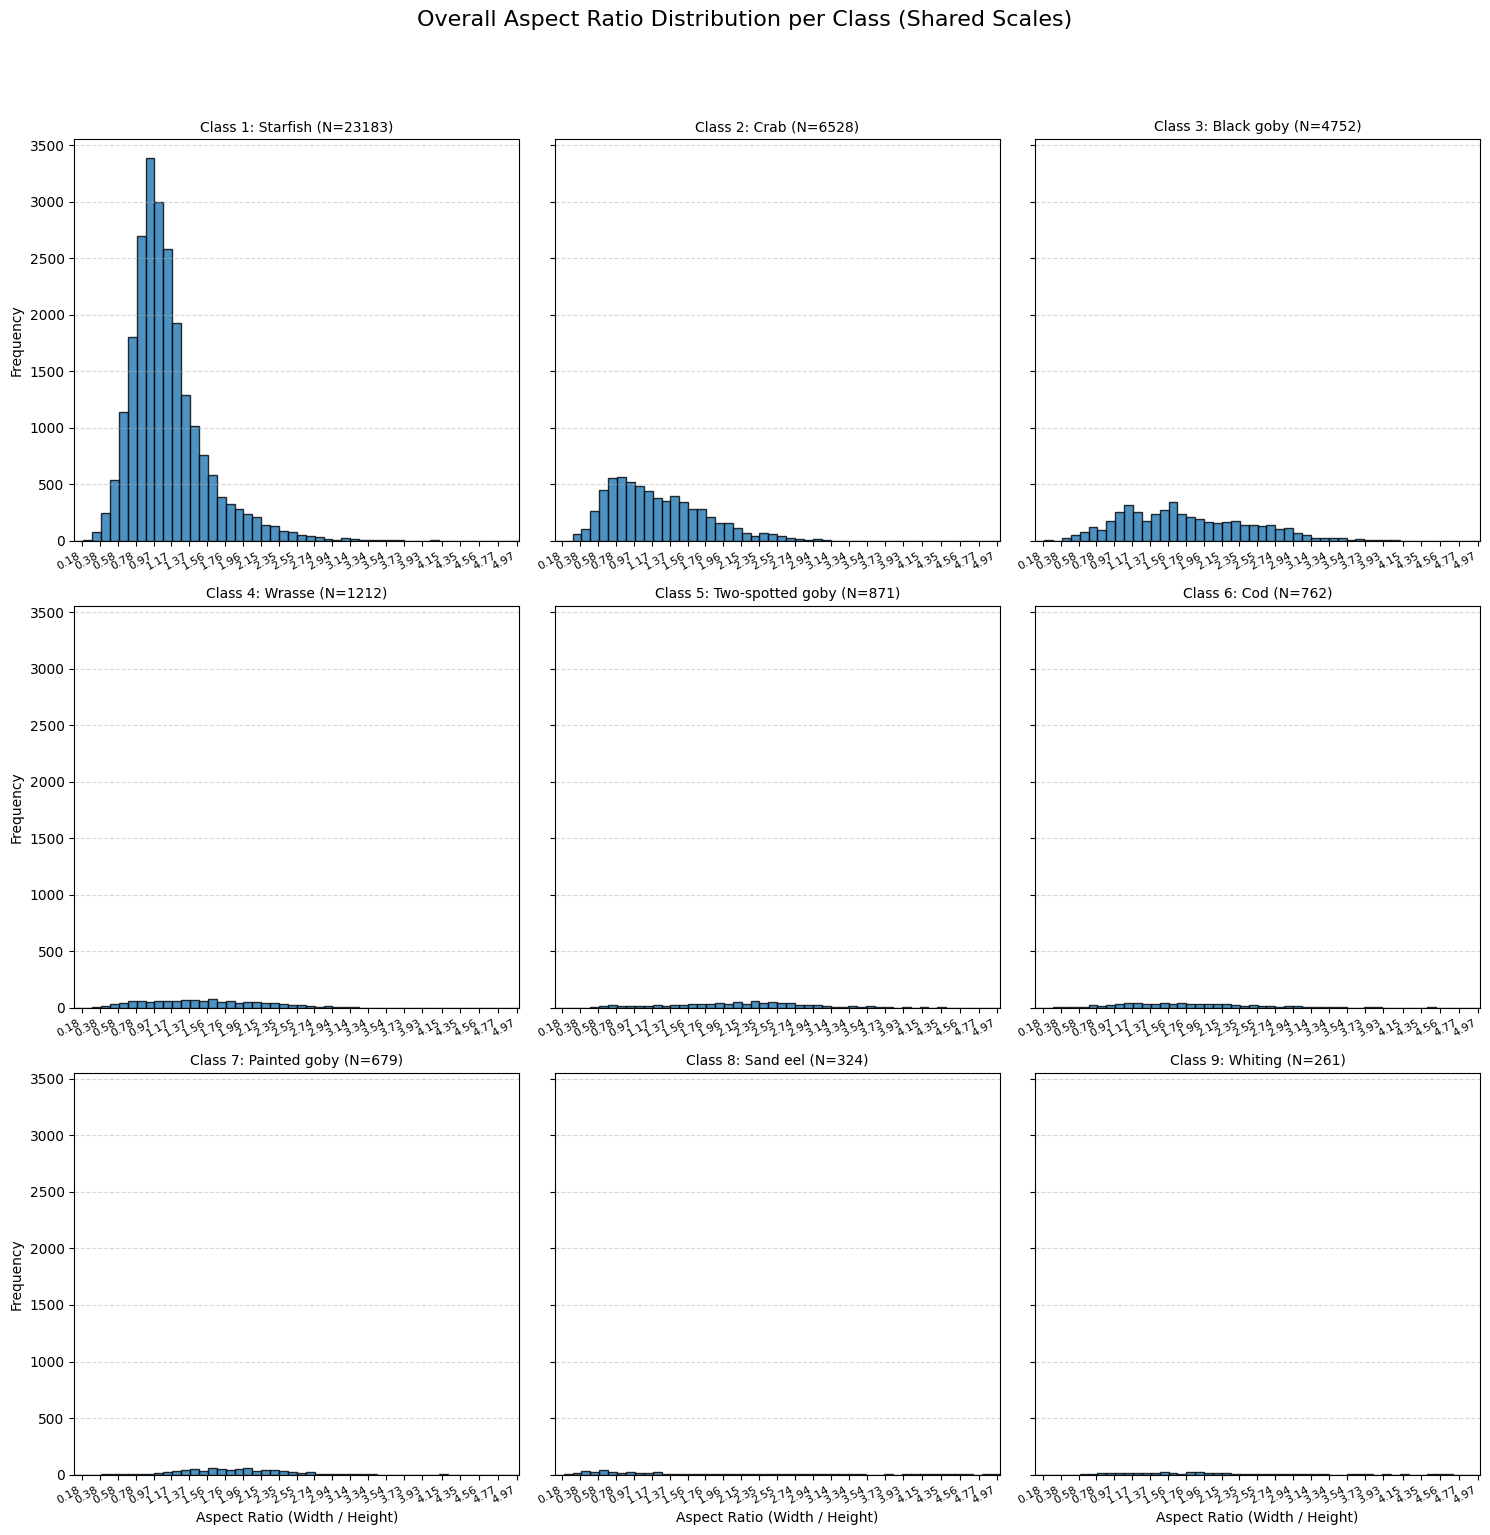

In [16]:

# 2. Plot the 3x3 overall histograms (Goal 2)
plot_overall_ratio_histograms_3x3(overall_ratio_data)


In [17]:

# 3. Extract data for the 1x9 plot (Kept vs. Deleted Ratios)
filtered_ratio_data = extract_filtered_ratios(KEPT_PATHS_FILE, DELETED_PATHS_FILE)


1. Extracting filtered ratio data...
   Processed 29047 kept images.
   Processed 9525 deleted images.


✅ Comparative multi-histogram saved to: ratio_histograms_kept_vs_deleted_1xN_all_xticks.png


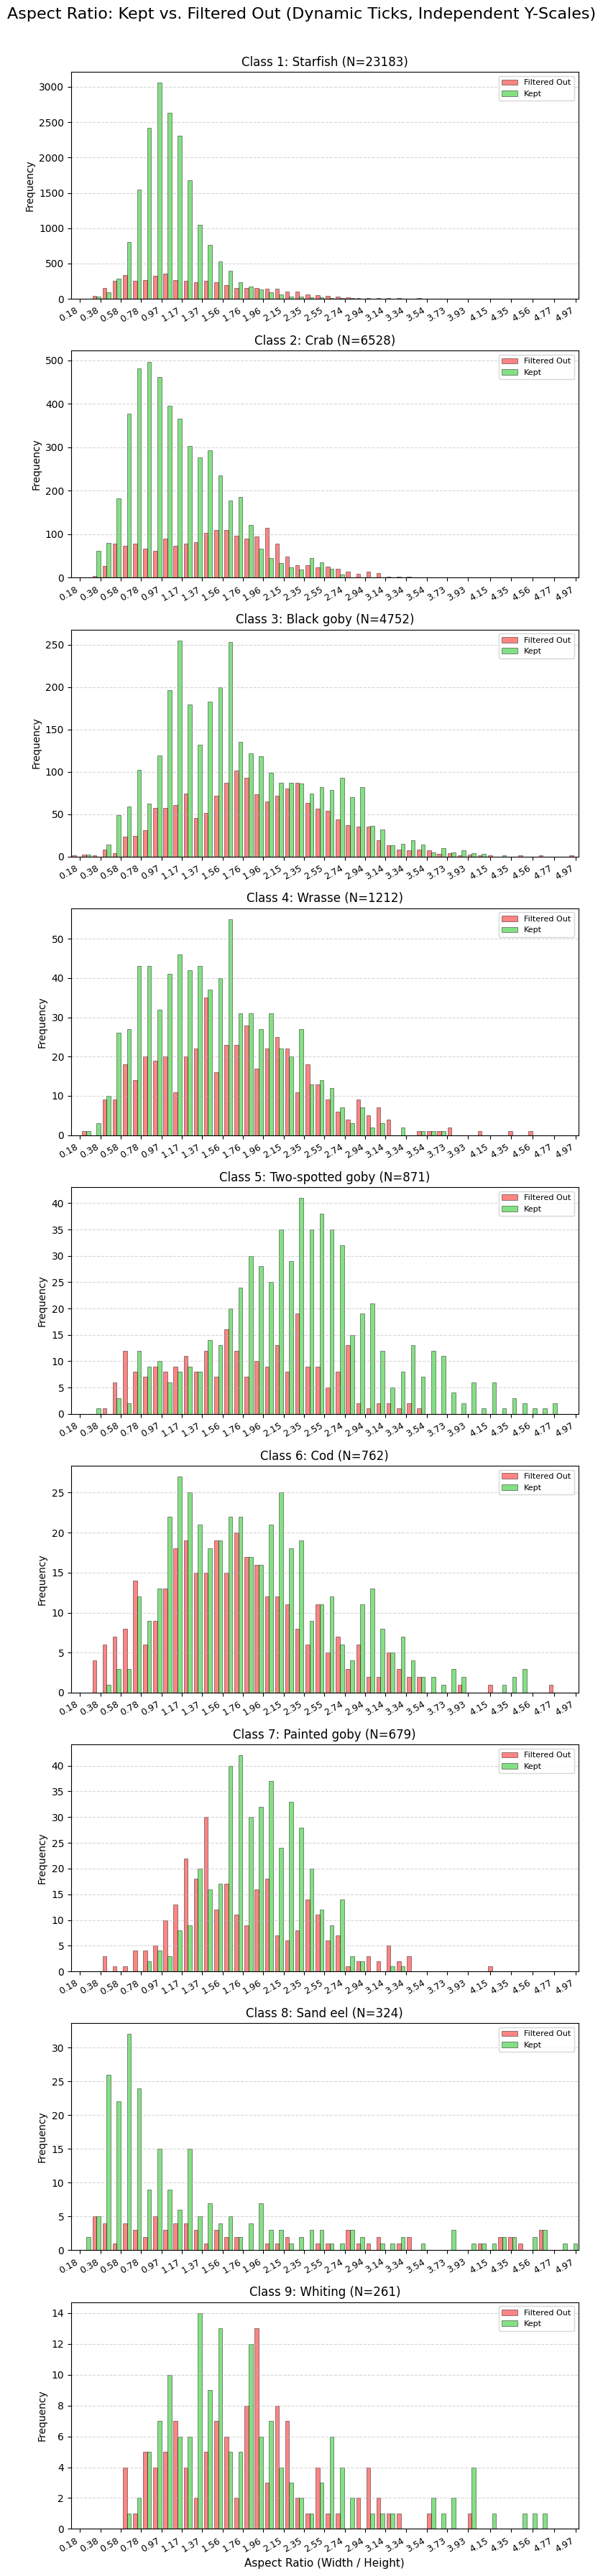

In [18]:

# 4. Plot the 1x9 kept/deleted comparative histograms (Goal 3)
plot_filtered_ratio_histograms_1x9_dynamic(filtered_ratio_data)